In [1]:
from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt

# Dynamics of fields in a Fabry-Perot cavity

The dynamics are described by the difference equation (Rakhmanov Eq. 1.50):

$E(t) = t_a E_\mathrm{in}(t) + r_a r_b e^{-2 i k d(t)} E(t-2T)$

where:
* $t_a$ is the transmissivity of the input mirror;
* $E_\mathrm{in}(t)$ is input laser field;
* $r_a$ and $r_b$ are the reflectivities of the mirrors (a - input, b - output);
* $k = \omega / c = 2\pi / \lambda$ is the wavenumber;
* $d(t) = L + x_b(t-T) - x_a(t) = L + \xi$ is physical length of the cavity (Rakhmanov Eq. 1.33);
* $T = \frac{L}{c}$ is half of the round-trip time;
* $L$ is half of the round-trip;
* $E(t-2T)$ is the field inside the cavity at the time before one round-trip.

In [2]:
t_a = 0.1
r_a = 0.9
r_b = 0.9
L = 3000  # m
T = L/const.c  # s
E_in = 1  #
lambd = 1064e-9  # m
k = 2*np.pi / lambd

Loss = 1. - np.power(t_a,2) - np.power(r_a,2)
if  Loss < 0.:
    print("Attenti ai valori")
else:
    print("Loss: {0}".format(Loss))

Loss: 0.17999999999999994


In [3]:
def N_eff(r_a, r_b):
    '''
    Effective number of photon round trips in a FabryPerot cavity (Rakhmanov Eq. 1.57)
    '''
    return 1./np.abs(np.log(r_a*r_b))

## Finesse and cavity decay time

Coefficient of finesse:

$F = \frac{4 r_a r_b}{(1 - r_a r_b)^2}$

$\tau_s = \frac{FL}{c\pi}$

Finesse ($\mathcal{F}$) of the cavity:

$\mathcal{F} = \frac{\pi}{2} \sqrt{F}$

Approximately: $\mathcal{F} = \pi N_\mathrm{eff}$

In [4]:
def F():
    '''
    Coefficient of finesse
    '''
    return 4.*r_a*r_b / np.power(1.-r_a*r_b, 2)

def tau_s():
    '''
    Formula equivalent to Eq. 2.17 (Rakhmanov)

    return 2. * T * N_eff(r_a, r_b)
    '''
    return F() * L / (np.pi * const.c)

def Finesse(F):
    '''
    Finesse
    '''
    return np.sqrt(F) * np.pi / 2.

In [5]:
print("Coefficient of finesse: {0:.2f}".format(F()))

print("Tau_s: {0}".format(tau_s()))

print("Finesse: {0}".format(Finesse(F())))

Coefficient of finesse: 89.75
Tau_s: 0.0002858831030486214
Finesse: 14.881228359109551


## Critical velocity

$v_\mathrm{cr} = \frac{\lambda}{2\tau\mathcal{F}}$

where $\tau$ is the storage time:

$\tau = 2 T N_\mathrm{eff}$

In [6]:
def tau():
    return 2. * T * N_eff(r_a, r_b)

In [7]:
def v_cr():
    return lambd / (2. * Finesse(F()) * tau())  # In [m/s]!

In [8]:
v_cr()

0.0003764004958010008

## Airy function

In [9]:
def Airy(F, phi):
    return 1. / (1. + F * np.sin(phi)**2)

## Cavity gain

$E = g A$

where $g$ ia the amplitude gain of the Fabry-Perot cavity:

$g = \frac{t_a}{1-r_a r_b}$

Power gain:

$P = g^2 P_\mathrm{in}$

In [10]:
def gain():
    return t_a / (1. - r_a*r_b)

## Cavity parameters summary

In [11]:
N_eff(r_a, r_b)

4.745610790514953

In [12]:
T

1.0006922855944561e-05

In [13]:
gain()

0.5263157894736844

## Some cases of $d(t)$

* $d(t) = const.$
* $d(t) = A\sin(2\pi f t)$
* $d(t) = arb(t)$ -- arbitrary function of time

In [14]:
v = 1.e-6/0.1  # m/s
#v = 0.00037640

def d(t):
    # Constant
    #return 2

    # Linear    
    #c = 1.
    return v*t + L

    # Sinusoidal
    A = 1.e-7
    f = 200.e6  # Hz
    #return A*np.sin(2.*np.pi*f*t)

In [15]:
def E_in(t):
    return 1.
    #return A*np.sin(2.*np.pi*f*t)

In [16]:
def x_a(t):
    return 0.0

In [17]:
def S_n(t, n, T):
    '''
    2 S_n is the optical path length for a photon which completed n round trips in the cavity.
    
    t - time
    n - "order" of S function (number of round-trips)
    T - half of the cavity round-trip time
    '''
    S = 0
    for p in np.arange(1, n+1, 1):
        S = S + d(t - 2.*T*p)
    return S

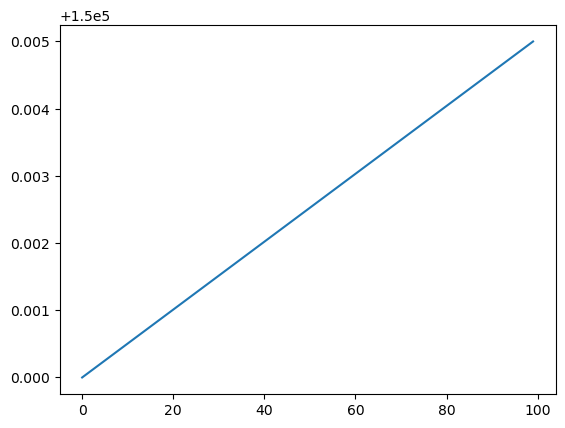

In [18]:
tdata = np.linspace(0,10,100)

res = np.zeros(100)

for idx, t in enumerate(tdata):
    res[idx] = S_n(t, 50, T)
    #print(dat)
#print(y)

plt.plot(res)

## Implementation of Eq. 1.51

In [19]:
N = 100  # Seems reasonable to sum up to 5 to 10 N_eff.
n = np.arange(0, N+1, 1)
rarbn = np.power(r_a*r_b, n) 

def E(t, N=0, recursion_level=0):
    #if t < 0.:
    #    return 0.

    if recursion_level > 100:  # TODO: Verify the accuracy!
        return 0.
        
    global t_a, r_a, r_b, T
    
    if N == 0:
        N = int(N_eff(r_a, r_b) * 5)

    '''
    if False:
        print("T_a: {0}".format(t_a))
        print("(r_a*r_b)^2: {0}".format(np.power(r_a*r_b, N)))
        print(k*S_n(t, N, T))
        #print(E(t-2.*N*T, N))
        print("--------")
    '''
    
    k2j = -2.j*k
    
    Sum = 0
    Sn = 0.
    for idx, p in enumerate(np.arange(1, N+1, 1)):
        Sum = Sum + rarbn[idx] * np.exp(k2j*Sn) * E_in(t-2.*p*T)
        Sn = Sn + d(t - 2.*T*p)

    try:
        E_last = E(t - 2.*N*T, N, recursion_level=recursion_level+1)
    except RecursionError:
        print("Recursion lvl: {0}".format(recursion_level))
        E_last = 0.
        
    res = t_a * Sum + rarbn[int(N)] * np.exp(k2j*Sn) * E_last
    return res

In [20]:
E(0.01)

(0.05537595588718789+0.00761736027833947j)

In [21]:
number_of_points = 1000

tdata = np.linspace(0., .1, number_of_points)

res = np.zeros(number_of_points, dtype=np.complex_)
ein = np.zeros(number_of_points, dtype=np.complex_)
eref = np.zeros(number_of_points, dtype=np.complex_)

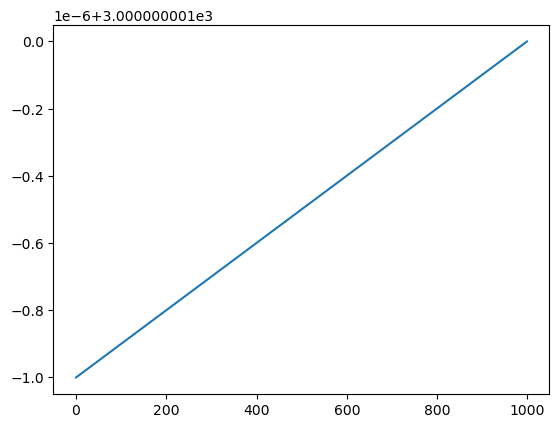

In [22]:
plt.plot(d(tdata))

In [23]:
for idx, t in enumerate(tdata):
    ein[idx] = E_in(t)
    res[idx] = E(t, N=25)

In [24]:
Adata = Airy(F(), (tdata*k-.1867895)*v)

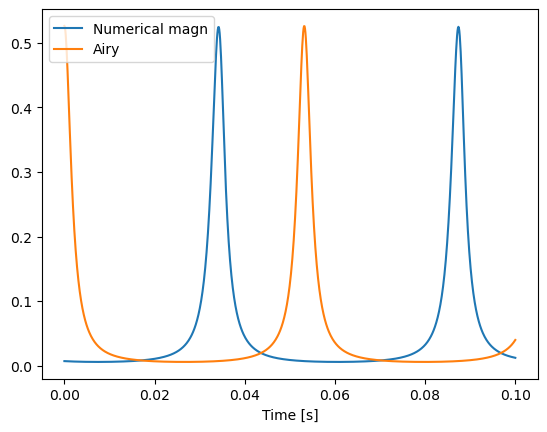

In [25]:
plt.plot(tdata, abs(res)**2/gain(), label="Numerical magn")
#plt.plot(tdata, np.angle(res), label="Numerical phase")

plt.plot(tdata, Adata*gain(), label="Airy")
plt.xlabel("Time [s]")
plt.legend()

# TODO:
    1. Delay factor (0.013 in Adata)
    2. Reproduce FigureFigure2.5 (Rakhmanov)

## Implementation of Eq 2.69

In [26]:
def D_0(Ein, V):
    return t_a*Ein*np.sqrt(np.pi * complex(0,1)/2.*k*V*T)*np.exp(complex(0,1)*T/2.*k*V*tau()**2)

In [27]:
def E_cr(t, Ein, V):
    return D_0(Ein, V)*np.exp(-t/tau() - complex(0,1)*k*V*t**2./2.*T) + t_a*Ein/(1-r_a*r_b*np.exp(-2.j*k*V*t))

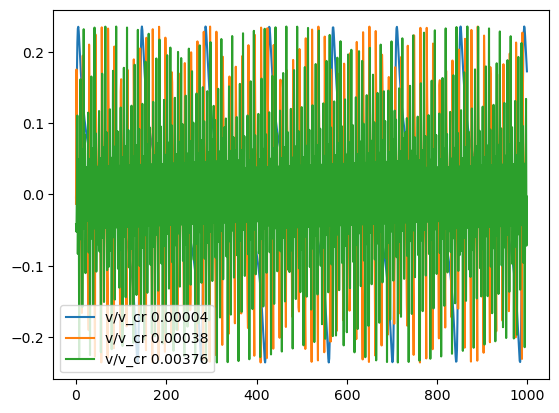

In [28]:
vel = [v_cr()/10, v_cr(), v_cr()*10]
res_scan = {}
for i, j in zip([0,1,2], vel):
    res_scan[i] = E_cr(tdata, ein, j)
    plt.plot(-res_scan[i].imag, label="v/v_cr {0:.5f}".format(j))
    plt.legend()

## Figure 2.6 $\frac{v}{v_{cr}} = 0.1$

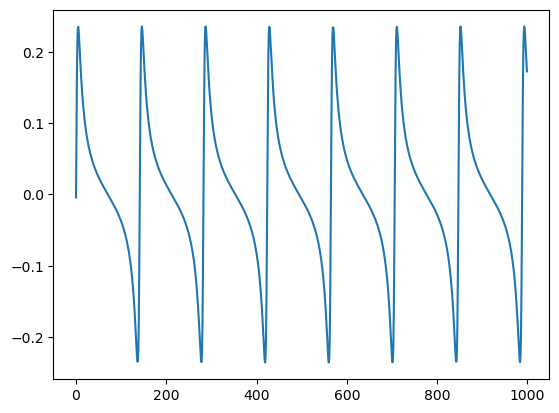

In [29]:
plt.plot(-res_scan[0].imag)

## Figure 2.6 $\frac{v}{v_{cr}} = 1$

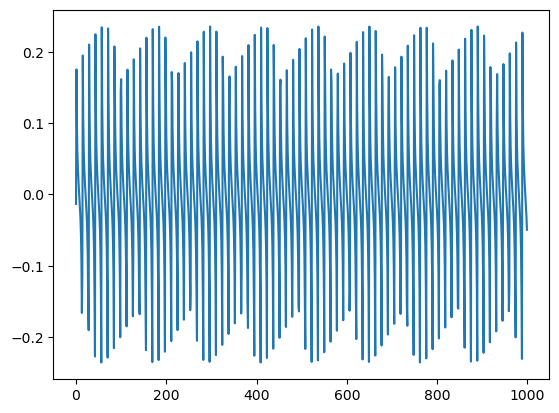

In [30]:
plt.plot(-res_scan[1].imag)

## Figure 2.6 $\frac{v}{v_{cr}} = 10$

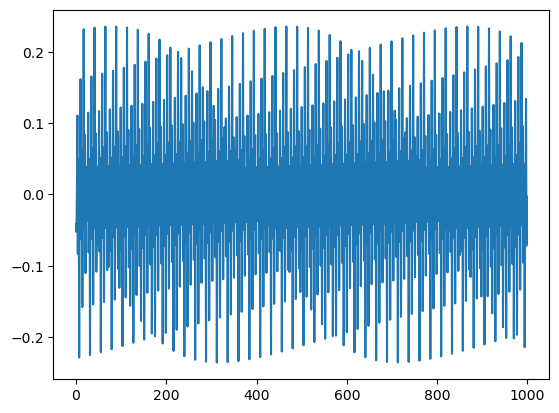

In [31]:
plt.plot(-res_scan[2].imag)

# Pound-Drever-Hall

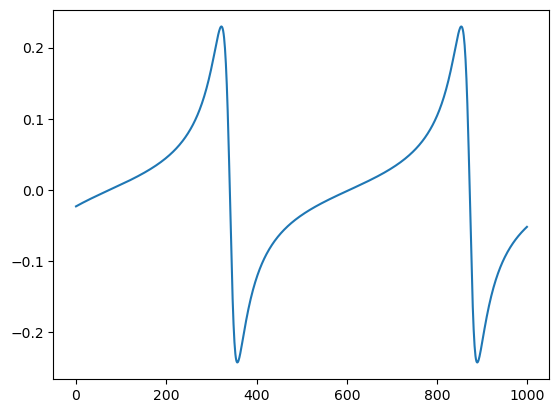

In [32]:
plt.plot(res.imag)

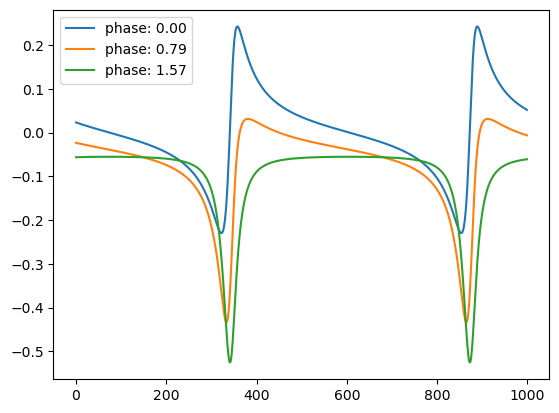

In [33]:
gamma = np.pi/2
def V_pdh(gamma):
    return -(np.exp(gamma*1.j) * np.conjugate(ein) * res).imag

for i in np.linspace(0., np.pi/2, 3):
    plt.plot(V_pdh(i), label="phase: {0:.2f}".format(i))

plt.legend()

In [34]:
def E_ref(t, Edt):
    return np.exp(-2.j*k*x_a(t)) * ((r_a**2 + t_a**2)*E_in(t) - t_a * Edt) / r_a


for idx, t in enumerate(tdata):
    ein[idx] = E_in(t)
    res[idx] = E(t, N=25)
    eref[idx] = E_ref(t, res[idx])

R_coeff = eref/ein

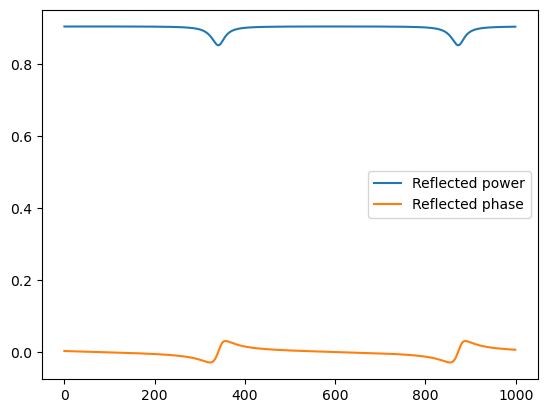

In [35]:
plt.plot(np.abs(R_coeff), label="Reflected power")
plt.plot(np.angle(R_coeff), label="Reflected phase")
plt.legend()

# TODO:
    1. Confrontare Reflected power to model in Finesse